In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader
from datasets import EEGDenoiseDatasetOverfit
from pathlib import Path
from resunet import DeepDSP_UNetRes

import mne

In [11]:
raw = mne.io.read_raw_brainvision('current_study_data_raw/H091/H091_scan.vhdr', preload=True)

chs = raw.info["ch_names"][0:24]

raw.pick(chs)

#raw.crop(tmin=460.876, tmax= 1430.472)
raw.crop(tmin=469.876, tmax= 1427.472)
raw.set_annotations(None)
raw.plot()
#raw.resample(512.)

Extracting parameters from current_study_data_raw/H091/H091_scan.vhdr...
Setting channel info structure...
Reading 0 ... 23571299  =      0.000 ...  4714.260 secs...


C:\Users\np3106\AppData\Local\Temp\ipykernel_12416\3920256625.py:1: RuntimeWarning: No coordinate information found for channels ['M1', 'M2', 'EMG1', 'EMG2', 'EMG3', 'ECG']. Setting channel types to misc. To avoid this warning, set channel types explicitly.
  raw = mne.io.read_raw_brainvision('current_study_data_raw/H091/H091_scan.vhdr', preload=True)
C:\Users\np3106\AppData\Local\Temp\ipykernel_12416\3920256625.py:1: RuntimeWarning: Not setting positions of 6 misc channels found in montage:
['M1', 'M2', 'EMG1', 'EMG2', 'EMG3', 'ECG']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_brainvision('current_study_data_raw/H091/H091_scan.vhdr', preload=True)


Using qt as 2D backend.


Channels marked as bad:
none


In [48]:
watermelon = mne.io.read_raw_brainvision('current_study_data_raw/watermelon2.0/watermelon2.0_scan.vhdr', preload=True)

chs = [
   'Fp1']
watermelon.pick(chs)
watermelon.crop(tmin=1855.415, tmax=2813.099)
watermelon.set_annotations(None)
watermelon.plot()
#watermelon.resample(512.)

Extracting parameters from current_study_data_raw/watermelon2.0/watermelon2.0_scan.vhdr...
Setting channel info structure...
Reading 0 ... 17386799  =      0.000 ...  3477.360 secs...


C:\Users\np3106\AppData\Local\Temp\ipykernel_11296\675968258.py:1: RuntimeWarning: No coordinate information found for channels ['EMG1', 'EMG2', 'EMG3', 'ECG']. Setting channel types to misc. To avoid this warning, set channel types explicitly.
  watermelon = mne.io.read_raw_brainvision('current_study_data_raw/watermelon2.0/watermelon2.0_scan.vhdr', preload=True)
C:\Users\np3106\AppData\Local\Temp\ipykernel_11296\675968258.py:1: RuntimeWarning: Not setting positions of 4 misc channels found in montage:
['EMG1', 'EMG2', 'EMG3', 'ECG']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  watermelon = mne.io.read_raw_brainvision('current_study_data_raw/watermelon2.0/watermelon2.0_scan.vhdr', preload=True)


Channels marked as bad:
none
Channels marked as bad:
none
Channels marked as bad:
none


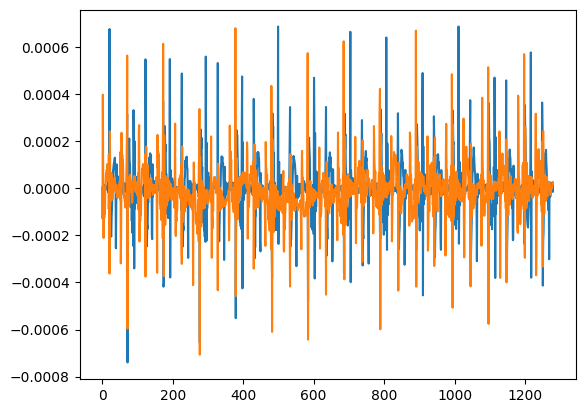

In [60]:
watermelon = np.load('data_segmented_one_subject_20_TR/watermelon.npy')
human = np.load('data_segmented_one_subject_20_TR/91/contaminated.npy')
plt.plot(watermelon[0,0,0:2000] , label='watermelon')
plt.plot(human[0,0,0:2000])

In [31]:
watermelon = mne.io.read_raw_brainvision('current_study_data_raw/watermelon2.0/watermelon2.0_scan.vhdr', preload=True)

chs = [
   'Fp1','Fp2','F3','F4','C3','C4','P3','P4','O1','O2',
  'F7','F8','T7','T8','P7','P8','FPz','Fz','Cz','Pz',
   'POz','Oz','FT9','FT10',"TP9'","TP10'",
   ]
watermelon.pick(chs)
watermelon.crop(tmin=1855.415, tmax=2813.099)
watermelon.set_annotations(None)
watermelon.resample(512.)
watermelon.plot()

Extracting parameters from current_study_data_raw/watermelon2.0/watermelon2.0_scan.vhdr...
Setting channel info structure...
Reading 0 ... 17386799  =      0.000 ...  3477.360 secs...


C:\Users\np3106\AppData\Local\Temp\ipykernel_11296\3619867569.py:1: RuntimeWarning: No coordinate information found for channels ['EMG1', 'EMG2', 'EMG3', 'ECG']. Setting channel types to misc. To avoid this warning, set channel types explicitly.
  watermelon = mne.io.read_raw_brainvision('current_study_data_raw/watermelon2.0/watermelon2.0_scan.vhdr', preload=True)
C:\Users\np3106\AppData\Local\Temp\ipykernel_11296\3619867569.py:1: RuntimeWarning: Not setting positions of 4 misc channels found in montage:
['EMG1', 'EMG2', 'EMG3', 'ECG']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  watermelon = mne.io.read_raw_brainvision('current_study_data_raw/watermelon2.0/watermelon2.0_scan.vhdr', preload=True)


Channels marked as bad:
none


In [12]:
raw = mne.io.read_raw_brainvision('current_study_data_raw/H091/H091_scan.vhdr', preload=True)

chs = raw.info["ch_names"][0:24]

raw.pick(chs)

raw.crop(tmin=469.876, tmax= 1427.472)
# raw.crop(tmin=460.876, tmax= 1430.472)
raw.set_annotations(None)
raw.resample(512.)

Extracting parameters from current_study_data_raw/H091/H091_scan.vhdr...
Setting channel info structure...
Reading 0 ... 23571299  =      0.000 ...  4714.260 secs...


C:\Users\np3106\AppData\Local\Temp\ipykernel_12416\3308364998.py:1: RuntimeWarning: No coordinate information found for channels ['M1', 'M2', 'EMG1', 'EMG2', 'EMG3', 'ECG']. Setting channel types to misc. To avoid this warning, set channel types explicitly.
  raw = mne.io.read_raw_brainvision('current_study_data_raw/H091/H091_scan.vhdr', preload=True)
C:\Users\np3106\AppData\Local\Temp\ipykernel_12416\3308364998.py:1: RuntimeWarning: Not setting positions of 6 misc channels found in montage:
['M1', 'M2', 'EMG1', 'EMG2', 'EMG3', 'ECG']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_brainvision('current_study_data_raw/H091/H091_scan.vhdr', preload=True)


<RawBrainVision | H091_scan.eeg, 24 x 490289 (957.6 s), ~89.8 MiB, data loaded>

In [23]:
raw.ch_names

['Fp1',
 'Fp2',
 'F3',
 'F4',
 'C3',
 'C4',
 'P3',
 'P4',
 'O1',
 'O2',
 'F7',
 'F8',
 'T7',
 'T8',
 'P7',
 'P8',
 'Fpz',
 'Fz',
 'Cz',
 'Pz',
 'POz',
 'Oz',
 'FT9',
 'FT10']

In [52]:
banana_pairs = [
    ('Fp1','F3'), ('F3', 'C3'), ('C3', 'P3'), ('P3', 'O1'), # left parasagittal
    ('Fp2','F4'), ('F4', 'C4'), ('C4', 'P4'), ('P4', 'O2'), # right parasagittal
    ('Fz', 'Cz'), ('Cz', 'Pz'),                             # vertex
    ('Fp1','F7'), ('F7', 'T7'), ('T7', 'P7'), ('P7', 'O1'), # left temporal
    ('Fp2','F8'), ('F8', 'T8'), ('T8', 'P8'), ('P8', 'O2'), # right temporal
    
]

raw_banana = mne.set_bipolar_reference(
    raw,
    anode=[a for a,b in banana_pairs],
    cathode=[b for a,b in banana_pairs],
    ch_name=[f"{a}-{b}" for a,b in banana_pairs],
    drop_refs=False   # keep originals too
)

X_raw = raw.get_data()
X_bip = raw_banana.get_data()

# Compare RMS or PSD in the artefact band
rms_raw = np.sqrt((X_raw**2).mean(axis=1)).mean()
rms_bip = np.sqrt((X_bip**2).mean(axis=1)).mean()
print("RMS reduction:", 100*(1 - rms_bip/rms_raw), "%")
raw_banana.plot()

EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=18, n_times=4787981
    Range : 2349380 ... 7137360 =    469.876 ...  1427.472 secs
Ready.
Added the following bipolar channels:
Fp1-F3, F3-C3, C3-P3, P3-O1, Fp2-F4, F4-C4, C4-P4, P4-O2, Fz-Cz, Cz-Pz, Fp1-F7, F7-T7, T7-P7, P7-O1, Fp2-F8, F8-T8, T8-P8, P8-O2
RMS reduction: 14.377722221353928 %


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x0000019AAE67A0C0>
Traceback (most recent call last):
  File "c:\Users\np3106\EEG_Cleaning_NaMRI\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1663, in __del__
    self._shutdown_workers()
  File "c:\Users\np3106\EEG_Cleaning_NaMRI\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1621, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


In [2]:
import matplotlib.pyplot as plt
import numpy as np

CH_NAMES = [           # optional: if you want channel names
    'Fp1','Fp2','F3','F4','C3','C4','P3','P4','O1','O2',
    'F7','F8','T7','T8','P7','P8','FPz','Fz','Cz','Pz',
    'POz','Oz','FT9','FT10',"TP9'","TP10'"
]

val_ds = EEGDenoiseDatasetOverfit(Path("data_segmented_one_subject_10_TR/91"))
val_dl = DataLoader(val_ds, batch_size=1, shuffle=False,
                    num_workers=2, pin_memory=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DeepDSP_UNetRes(in_channels=1, out_channels=1, nb=6).to(device)
model.load_state_dict(torch.load('best_model_eeg_one_subject_10_TR_unet_new_interference_0_sensors.pt', map_location=torch.device('cpu')))
model.eval()

full_cleaned = []
full_contam = []
full_y = []
with torch.no_grad():
    for batch_idx, (x,y, epoch_i, noise_i, m, sd, ch) in enumerate(val_dl):
        x= x.to(device)
        y=y.to(device)
        m, sd = m.to(device),  sd.to(device)      # (B,) → scalars

        m  = m.view(-1, 1, 1)                     # (B,1,1)
        sd = sd.view(-1, 1, 1)                    # (B,1,1)
        
        cleaned = model(x)

        # pred_noise = model2(x)
        cleaned_output = x[:, 0:1, :] - cleaned # Normalized output
        cleaned_output_raw = cleaned_output * sd + m # Denormalized outpu

        #cleaned = cleaned*sd + m
        cleaned_np = cleaned_output_raw.cpu().numpy().squeeze(1)


        x_raw = x*sd + m
        contam_np = x_raw[:,0,:].cpu().numpy()

        y_clean = y*sd + m
        y_np = y_clean[:,0,:].cpu().numpy()

        full_cleaned.append(cleaned_np)
        full_contam.append(contam_np)
        full_y.append(y_np)
full_cleaned = np.concatenate(full_cleaned, axis=1)
full_contam = np.concatenate(full_contam, axis=1)
full_y = np.concatenate(full_y, axis=1)

c:\Users\np3106\EEG_Cleaning_NaMRI\.venv\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


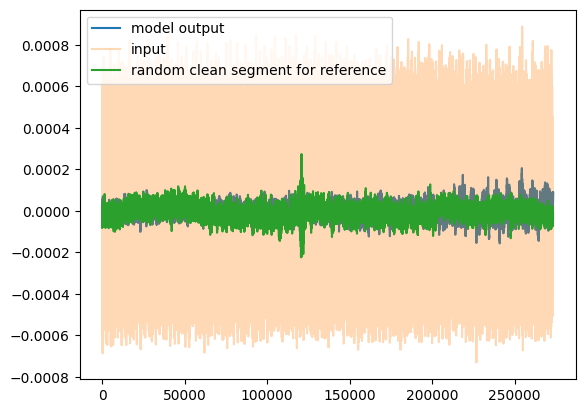

In [ ]:
# best_model_eeg_one_subject_10_TR_unet_new_interference_0_sensors
plt.plot(full_cleaned[0][:], label='model output')
plt.plot(full_contam[0][:], alpha=0.3, label='input')
plt.plot(full_y[0][:], label = 'random clean segment for reference')
plt.legend()

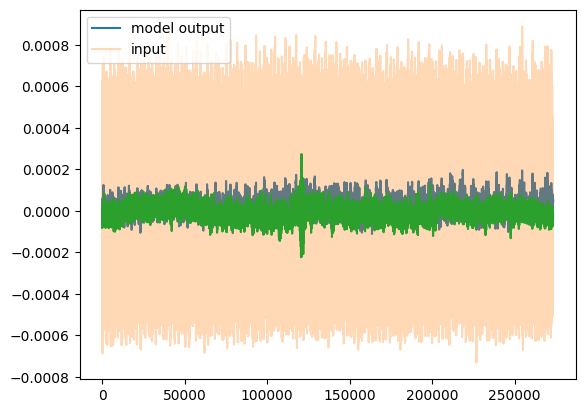

In [ ]:
# best_model_eeg_one_subject_10_TR_unet_new_interference_0_sensors_one_channel_32_bs_5e5
plt.plot(full_cleaned[0][:], label='model output')
plt.plot(full_contam[0][:], alpha=0.3, label='input')
plt.plot(full_y[0][:])
plt.legend()


In [13]:
def denoised(arr):
    assert arr.shape[1] >= full_cleaned.shape[1], "Raw object too short for full_cleaned"

    # Replace only the first full_cleaned.shape[1] timepoints
    arr[:, :full_cleaned.shape[1]] = full_cleaned
    return arr

k = raw.copy()
k.apply_function(denoised, channel_wise=False)
k.plot()

In [14]:
#raw.plot()
raw.plot()

In [15]:
raw_clean = mne.io.read_raw_brainvision('current_study_data_raw/H091/H091_scan.vhdr', preload=True)

chs = [
   'Fp1'
   ]
raw_clean.pick(chs)
raw_clean.crop(tmin=342.988, tmax= 469.876)
raw_clean.set_annotations(None)
raw_clean.resample(512.)

Extracting parameters from current_study_data_raw/H091/H091_scan.vhdr...
Setting channel info structure...
Reading 0 ... 23571299  =      0.000 ...  4714.260 secs...


C:\Users\np3106\AppData\Local\Temp\ipykernel_12416\4042735476.py:1: RuntimeWarning: No coordinate information found for channels ['M1', 'M2', 'EMG1', 'EMG2', 'EMG3', 'ECG']. Setting channel types to misc. To avoid this warning, set channel types explicitly.
  raw_clean = mne.io.read_raw_brainvision('current_study_data_raw/H091/H091_scan.vhdr', preload=True)
C:\Users\np3106\AppData\Local\Temp\ipykernel_12416\4042735476.py:1: RuntimeWarning: Not setting positions of 6 misc channels found in montage:
['M1', 'M2', 'EMG1', 'EMG2', 'EMG3', 'ECG']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw_clean = mne.io.read_raw_brainvision('current_study_data_raw/H091/H091_scan.vhdr', preload=True)


<RawBrainVision | H091_scan.eeg, 1 x 64967 (126.9 s), ~524 KiB, data loaded>

In [16]:
raw_clean.plot()

Channels marked as bad:
none
Channels marked as bad:
none
Channels marked as bad:
none
